# Respiratory Disease Classification — D1 + D2 + D3 → Combined Dataset
**Pipeline:** Audio → Mel Spectrogram → **Merge D1, D2 & D3** → Augmentation → RDLINet → 5-Fold CV

| Dataset | Original Classes | Snippets |
|---------|-----------------|----------|
| D1 (ICBHI) | Bronchiectasis, Bronchiolitis, COPD, Healthy, Pneumonia, URTI | preprocessed separately |
| D2 | Asthma, COPD, Healthy, Pneumonia | preprocessed separately |
| D3 | *(your D3 classes here)* | preprocessed separately |

**Unified class set:** Asthma, Bronchiectasis, Bronchiolitis, COPD, Healthy, Pneumonia, URTI *(plus any D3-exclusive classes)*

> Overlapping classes (COPD, Healthy, Pneumonia) are **merged** — snippets from D1, D2, and D3 are pooled into the same class index.


In [ ]:
# ── Cell 1 : Mount Google Drive ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Cell 2 : Paths & Directories ────────────────────────────────────────────
import os

# ---- D1 (ICBHI) ----
AUDIO_PATH_D1  = '/content/drive/MyDrive/Task 1/D1/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files'
LABELED_CSV_D1 = '/content/drive/MyDrive/Task 1/D1/Respiratory_Sound_Database/Respiratory_Sound_Database/labeled_files.csv'
PROCESSED_D1   = '/content/drive/MyDrive/Task2_Processed'

# ---- D2 ----
AUDIO_PATH_D2  = '/content/drive/MyDrive/Task 1/D2/audio_files'
LABELED_CSV_D2 = '/content/drive/MyDrive/Task 1/D2/d2_labeled.csv'
PROCESSED_D2   = '/content/drive/MyDrive/D2_Processed'

# ---- D3 ----
AUDIO_PATH_D3  = '/content/drive/MyDrive/Task 1/D3/RespiratoryDatabase@TR'
LABELED_CSV_D3 = '/content/drive/MyDrive/Task 1/D3/final_ml_dataset3.csv'
PROCESSED_D3   = '/content/drive/MyDrive/D3_Processed'
# ---- Combined output ----
PROCESSED_COMBINED   = '/content/drive/MyDrive/Combined_Processed'
RESULTS_DIR_COMBINED = '/content/drive/MyDrive/Combined_Results'

for d in [PROCESSED_D1, PROCESSED_D2, PROCESSED_D3, PROCESSED_COMBINED, RESULTS_DIR_COMBINED]:
    os.makedirs(d, exist_ok=True)

print('D1 audio exists :', os.path.exists(AUDIO_PATH_D1))
print('D1 CSV   exists :', os.path.exists(LABELED_CSV_D1))
print('D2 audio exists :', os.path.exists(AUDIO_PATH_D2))
print('D2 CSV   exists :', os.path.exists(LABELED_CSV_D2))
print('D3 audio exists :', os.path.exists(AUDIO_PATH_D3))
print('D3 CSV   exists :', os.path.exists(LABELED_CSV_D3))


D1 audio exists : True
D1 CSV   exists : True
D2 audio exists : True
D2 CSV   exists : True
D3 audio exists : True
D3 CSV   exists : True


In [ ]:
# ── Cell 3 : Imports ─────────────────────────────────────────────────────────
import gc
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import librosa
import cv2
from tqdm import tqdm

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, BatchNormalization,
    LeakyReLU, MaxPool2D, GlobalAveragePooling2D,
    Dropout, Dense, Multiply, Concatenate
)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report
)

print('TF version :', tf.__version__)
print('Librosa    :', librosa.__version__)

TF version : 2.20.0
Librosa    : 0.11.0


---
## Shared Utilities

In [ ]:
# ── Cell 4 : Audio → Mel-Spectrogram Image ───────────────────────────────────
def process_audio_to_images(wav_path, sr_target=4000):
    """
    Paper pipeline (Section III-A / III-C):
      1. Resample to 4 kHz
      2. 5-sec snippets with 50 % overlap
      3. DFT baseline-wander removal (0-1 Hz zeroed)
      4. Amplitude normalisation to [-1, 1]
      5. Mel spectrogram: 64 filters, n_fft=1024, hop=512, Hamming window
      6. Log-scale → resize 64×38 → Jet colormap → float32 [0,1]
    """
    images = []
    try:
        signal, _ = librosa.load(wav_path, sr=sr_target, mono=True)
    except Exception as e:
        print(f'  Error loading {wav_path}: {e}')
        return images

    win = 5 * sr_target
    hop = win // 2

    for start in range(0, len(signal) - win + 1, hop):
        snippet = signal[start : start + win].copy()

        # DFT baseline-wander removal
        N       = len(snippet)
        fft_val = np.fft.fft(snippet)
        freqs   = np.fft.fftfreq(N, 1.0 / sr_target)
        fft_val[np.abs(freqs) <= 1.0] = 0
        snippet = np.real(np.fft.ifft(fft_val))

        # Amplitude normalisation
        max_val = np.max(np.abs(snippet))
        if max_val > 0:
            snippet = snippet / max_val

        # Mel spectrogram
        mel    = librosa.feature.melspectrogram(
            y=snippet, sr=sr_target,
            n_fft=1024, hop_length=512,
            n_mels=64, window='hamming'
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Resize → Jet colormap → float32
        mel_resized = cv2.resize(mel_db, (38, 64))
        mel_norm    = cv2.normalize(
            mel_resized, None, 0, 255, cv2.NORM_MINMAX
        ).astype(np.uint8)
        mel_jet = cv2.applyColorMap(mel_norm, cv2.COLORMAP_JET)
        mel_rgb = cv2.cvtColor(mel_jet, cv2.COLOR_BGR2RGB)
        images.append(mel_rgb.astype('float32') / 255.0)

    return images

print('process_audio_to_images defined')

process_audio_to_images defined


In [ ]:
# ── Cell 5 : Augmentation Function ───────────────────────────────────────────
def augment_spectrogram(img):
    """
    Returns 10 augmented versions of one spectrogram image (H×W×C float32).

    Techniques applied
    ------------------
    1. Time-stretch  ×4  (factors 0.8 / 0.9 / 1.1 / 1.2)  — linear interp
    2. Additive noise ×3  (std 0.03 / 0.06 / 0.10)
    3. Frequency masking ×1  (random 16-row band zeroed)
    4. Time masking     ×1  (random 10-column band zeroed)
    5. Brightness shift ×1  (random scale in [0.85, 1.15])
    """
    aug     = []
    H, W, C = img.shape

    # ---- 1. Time-stretch ----
    for factor in [0.8, 0.9, 1.1, 1.2]:
        stretched = np.zeros((H, W, C), dtype='float32')
        new_len   = max(1, int(W * factor))
        x_new     = np.linspace(0, W - 1, new_len)
        x_old     = np.arange(W)
        for c in range(C):
            for row in range(H):
                interped = np.interp(x_new, x_old, img[row, :, c])
                if new_len < W:
                    interped = np.pad(interped, (0, W - new_len), mode='edge')
                else:
                    interped = interped[:W]
                stretched[row, :, c] = interped
        aug.append(stretched)

    # ---- 2. Additive Gaussian noise ----
    for noise_std in [0.03, 0.06, 0.10]:
        noisy = img + np.random.normal(0, noise_std, img.shape).astype('float32')
        aug.append(np.clip(noisy, 0.0, 1.0))

    # ---- 3. Frequency masking ----
    f_masked         = img.copy()
    f_start          = np.random.randint(0, H - 16)
    f_masked[f_start:f_start + 16, :, :] = 0
    aug.append(f_masked)

    # ---- 4. Time masking ----
    t_masked         = img.copy()
    t_start          = np.random.randint(0, W - 10)
    t_masked[:, t_start:t_start + 10, :] = 0
    aug.append(t_masked)

    # ---- 5. Brightness shift ----
    aug.append(
        np.clip(img * np.random.uniform(0.85, 1.15), 0.0, 1.0).astype('float32')
    )

    return aug   # 10 augmented images


def balance_dataset(X, Y, y_labels, class_list, target_count):
    """
    Augments minority classes until every class has `target_count` samples.
    Returns (X_balanced, Y_balanced, y_labels_balanced).
    """
    X_aug_list = [X]
    Y_aug_list = [Y]

    for cls_idx in range(len(class_list)):
        current = int((y_labels == cls_idx).sum())
        if current >= target_count:
            print(f'  Class {cls_idx} ({class_list[cls_idx]:22s}): {current:5d} — already >= target, skipping')
            continue

        X_min  = X[y_labels == cls_idx]
        Y_min  = Y[y_labels == cls_idx]
        needed = target_count - current
        added  = 0
        i      = 0

        while added < needed:
            for aug_img in augment_spectrogram(X_min[i % len(X_min)]):
                if added >= needed:
                    break
                X_aug_list.append(aug_img[np.newaxis])
                Y_aug_list.append(Y_min[i % len(Y_min)][np.newaxis])
                added += 1
            i += 1

        print(f'  Class {cls_idx} ({class_list[cls_idx]:22s}): {current:5d} -> {current + added}')

    X_bal = np.concatenate(X_aug_list, axis=0)
    Y_bal = np.concatenate(Y_aug_list, axis=0)
    y_bal = np.argmax(Y_bal, axis=1)
    return X_bal, Y_bal, y_bal

print('augment_spectrogram & balance_dataset defined')

augment_spectrogram & balance_dataset defined


In [ ]:
# ── Cell 6 : RDLINet Architecture ────────────────────────────────────────────
def RDLINet(dim, output_neurons, output_activation):
    """
    Residual Depthwise-separable Lightweight Inception Network.
    Each inception block fuses 1x1, DW3x3+PW, DW5x5+PW, MaxPool+PW branches.
    A GLU-like Dense gate head controls the final projection.
    """

    def inception_block(x, filters, reps):
        for _ in range(reps):
            t1 = Conv2D(filters[0], (1, 1), padding='same')(x)
            t1 = BatchNormalization()(t1)
            t1 = LeakyReLU()(t1)

            t2 = DepthwiseConv2D((3, 3), padding='same')(x)
            t2 = BatchNormalization()(t2)
            t2 = LeakyReLU()(t2)
            t2 = Conv2D(filters[1], (1, 1), padding='same')(t2)
            t2 = BatchNormalization()(t2)
            t2 = LeakyReLU()(t2)

            t3 = DepthwiseConv2D((5, 5), padding='same')(x)
            t3 = BatchNormalization()(t3)
            t3 = LeakyReLU()(t3)
            t3 = Conv2D(filters[2], (1, 1), padding='same')(t3)
            t3 = BatchNormalization()(t3)
            t3 = LeakyReLU()(t3)

            t4 = MaxPool2D((3, 3), strides=1, padding='same')(x)
            t4 = Conv2D(filters[3], (1, 1), padding='same')(t4)
            t4 = BatchNormalization()(t4)
            t4 = LeakyReLU()(t4)

            x = Concatenate()([t1, t2, t3, t4])
        return x

    k           = 32
    input_layer = Input(shape=dim)

    x = Conv2D(k, (3, 3), strides=2, padding='same')(input_layer)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)
    x = MaxPool2D((3, 3), strides=2, padding='same')(x)

    x = DepthwiseConv2D((3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)
    x = Conv2D(2 * k, (1, 1), padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)
    x = MaxPool2D((2, 2))(x)

    x = inception_block(x, [k, k, k, k], 2)
    x = MaxPool2D((2, 2))(x)

    x  = GlobalAveragePooling2D()(x)
    x  = Dropout(0.3)(x)
    g  = Dense(15, activation='sigmoid')(x)
    v  = Dense(15, activation='linear')(x)
    gv = Multiply()([g, v])

    output = Dense(output_neurons, activation=output_activation)(gv)
    return Model(input_layer, output, name='RDLINet')

print('RDLINet defined')
tmp = RDLINet((64, 38, 3), 7, 'softmax')
tmp.summary()
del tmp

RDLINet defined


Model: "RDLINet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 38, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 19,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 19,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 32, 19,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 10,    │          0 │ leaky_re_lu[0][0] │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 16, 10,    │        320 │ max_pooling2d[0]… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 10,    │        128 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 16, 10,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 10,    │      2,112 │ leaky_re_lu_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 10,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 16, 10,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 5, 64)  │          0 │ leaky_re_lu_2[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 8, 5, 64)  │        640 │ max_pooling2d_1[… │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_2  │ (None, 8, 5, 64)  │      1,664 │ max_pooling2d_1[… │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 5, 64)  │        256 │ depthwise_conv2d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 5, 64)  │        256 │ depthwise_conv2d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 8, 5, 64)  │          0 │ batch_normalizat

 Total params: 42,126 (164.55 KB)

 Trainable params: 40,590 (158.55 KB)

 Non-trainable params: 1,536 (6.00 KB)

In [ ]:
# ── Cell 7 : Training Helper ─────────────────────────────────────────────────
def run_kfold_training(
    X, Y, y_labels, class_list, results_dir, tag,
    n_splits=5, epochs=300, batch_size=128, lr=0.008
):
    H, W, C    = X.shape[1], X.shape[2], X.shape[3]
    n_classes  = len(class_list)
    kf         = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    acc_scores = []

    print(f'Input shape   : ({H}, {W}, {C})')
    print(f'Classes ({n_classes})  : {class_list}')
    print(f'Total samples : {len(X)}')

    for fold, (train_idx, test_idx) in enumerate(kf.split(X, y_labels), start=1):
        print(f'\n{"="*44}')
        print(f'  FOLD {fold} / {n_splits}  [{tag}]')
        print(f'{"="*44}')

        tf.keras.backend.clear_session()
        gc.collect()

        X_train, X_test = X[train_idx], X[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]

        model = RDLINet((H, W, C), n_classes, 'softmax')
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15,
                restore_best_weights=True
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5,
                patience=8, min_lr=1e-6, verbose=1
            )
        ]

        history = model.fit(
            X_train, Y_train,
            validation_data=(X_test, Y_test),
            epochs=epochs, batch_size=batch_size,
            callbacks=callbacks, verbose=1
        )

        # ── Predictions & Metrics ─────────────────────────────────────────────
        preds  = model.predict(X_test, verbose=0)
        y_pred = np.argmax(preds, axis=1)
        y_true = np.argmax(Y_test, axis=1)
        acc    = accuracy_score(y_true, y_pred)
        acc_scores.append(acc)

        print(f'\nFold {fold} Accuracy : {acc * 100:.4f}%')
        print(classification_report(y_true, y_pred,
                                    target_names=class_list, zero_division=0))

        # ── Confusion Matrix Data ─────────────────────────────────────────────
        cm         = confusion_matrix(y_true, y_pred)
        cm_percent = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)

        # ── Combined Figure ───────────────────────────────────────────────────
        fig = plt.figure(figsize=(15, 4.5))
        fig.patch.set_facecolor('white')

        # ── Plot 1 : Accuracy ─────────────────────────────────────────────────
        ax1 = fig.add_subplot(1, 3, 1)
        ax1.plot(history.history['accuracy'],     color='#00C853', linewidth=2, label='Train')
        ax1.plot(history.history['val_accuracy'], color='#D500F9', linewidth=2, label='Test')
        ax1.set_title('Model Accuracy', fontweight='bold')
        ax1.set_xlabel('No of Epochs')
        ax1.set_ylabel('Accuracy')
        ax1.legend()
        ax1.grid(True, linestyle='--', alpha=0.6)
        ax1.set_facecolor('white')

        # ── Plot 2 : Loss ─────────────────────────────────────────────────────
        ax2 = fig.add_subplot(1, 3, 2)
        ax2.plot(history.history['loss'],     color='#00C853', linewidth=2, label='Train')
        ax2.plot(history.history['val_loss'], color='#D500F9', linewidth=2, label='Test')
        ax2.set_title('Model Loss', fontweight='bold')
        ax2.set_xlabel('No of Epochs')
        ax2.set_ylabel('Loss')
        ax2.legend()
        ax2.grid(True, linestyle='--', alpha=0.6)
        ax2.set_facecolor('white')

        # ── Plot 3 : Confusion Matrix ─────────────────────────────────────────
        ax3 = fig.add_subplot(1, 3, 3)
        sns.heatmap(
         cm_percent, annot=True, fmt='.2f', cmap='YlOrRd',
         xticklabels=class_list, yticklabels=class_list,
         ax=ax3, linewidths=0.5, linecolor='white',
         vmin=0.0, vmax=1.0
        )
        ax3.set_title(f'RDLINet')
        ax3.set_xlabel('Predicted Labels', fontsize=10)
        ax3.set_ylabel('True Labels',      fontsize=10)
        ax3.set_xticklabels(class_list, rotation=45, ha='right',
                            fontsize=9, fontweight='bold', color='#111111')
        ax3.set_yticklabels(class_list, rotation=0,
                            fontsize=9, fontweight='bold', color='#111111')

        plt.tight_layout()
        plt.savefig(f'{results_dir}/{tag}_fold{fold}_combined.png', dpi=150, bbox_inches='tight')
        plt.show()

        # ── Save Weights ──────────────────────────────────────────────────────
        model.save_weights(f'{results_dir}/{tag}_fold{fold}.weights.h5')
        print(f'Fold {fold} weights saved.')

    # ── Final Summary ─────────────────────────────────────────────────────────
    results = {
        'tag'             : tag,
        'classes'         : class_list,
        'fold_accuracies' : [float(s * 100) for s in acc_scores],
        'mean_accuracy'   : float(np.mean(acc_scores) * 100),
        'std_accuracy'    : float(np.std(acc_scores) * 100)
    }
    with open(f'{results_dir}/{tag}_results.json', 'w') as f:
        json.dump(results, f, indent=2)

    print(f'\n{"="*44}')
    print(f'FINAL RESULTS — {tag}')
    print(f'{"="*44}')
    for i, s in enumerate(acc_scores, 1):
        print(f'  Fold {i} : {s * 100:.4f}%')
    print(f'  Mean  : {np.mean(acc_scores) * 100:.4f}%')
    print(f'  Std   : {np.std(acc_scores) * 100:.4f}%')
    return acc_scores

print('run_kfold_training defined')

run_kfold_training defined


---
## Part A — Preprocess D1 (ICBHI — 6 classes)
Run Cells 8-9 once, then use Cell 10 to reload on future runs.

In [ ]:
# ── Cell 8 : D1 — Load & Filter CSV ─────────────────────────────────────────
D1_CLASSES = [
    'Bronchiectasis', 'Bronchiolitis', 'COPD',
    'Healthy', 'Pneumonia', 'URTI'
]

df_d1 = pd.read_csv(LABELED_CSV_D1)
df_d1 = df_d1[
    df_d1['filename'].str.endswith('.wav') &
    df_d1['diagnosis'].isin(D1_CLASSES)
].reset_index(drop=True)

print(f'D1 wav files : {len(df_d1)}')
print(df_d1['diagnosis'].value_counts())

D1 wav files : 917
diagnosis
COPD              793
Pneumonia          37
Healthy            35
URTI               23
Bronchiectasis     16
Bronchiolitis      13
Name: count, dtype: int64


In [ ]:
# ── Cell 9 : D1 — Extract Mel-Spectrogram Images & Save ──────────────────────
# Run ONCE — skip on future runs (use Cell 10 instead)
X_d1_list, y_d1_list, skipped = [], [], 0

for _, row in tqdm(df_d1.iterrows(), total=len(df_d1), desc='D1 Audio'):
    wav_path = os.path.join(AUDIO_PATH_D1, row['filename'])
    if not os.path.exists(wav_path):
        skipped += 1
        continue
    for img in process_audio_to_images(wav_path):
        X_d1_list.append(img)
        y_d1_list.append(row['diagnosis'])

print(f'Skipped  : {skipped}')
print(f'Snippets : {len(X_d1_list)}')

X_d1     = np.array(X_d1_list, dtype='float32')
y_d1_raw = np.array(y_d1_list)

# Save with RAW string labels so merging is label-safe
np.save(f'{PROCESSED_D1}/X_d1.npy',        X_d1)
np.save(f'{PROCESSED_D1}/y_raw_d1.npy',    y_d1_raw)
print('D1 arrays saved.')

# Preview
unique, counts = np.unique(y_d1_raw, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {u:22s}: {c}')

D1 Audio: 100%|██████████| 917/917 [16:25<00:00,  1.08s/it]


Skipped  : 0
Snippets : 6916
D1 arrays saved.
  Bronchiectasis        : 112
  Bronchiolitis         : 91
  COPD                  : 6055
  Healthy               : 240
  Pneumonia             : 259
  URTI                  : 159


In [ ]:
# ── Cell 10 : D1 — Reload (future runs) ──────────────────────────────────────
X_d1     = np.load(f'{PROCESSED_D1}/X_d1.npy')
y_d1_raw = np.load(f'{PROCESSED_D1}/y_raw_d1.npy', allow_pickle=True)

print('D1 reloaded — X:', X_d1.shape)
unique, counts = np.unique(y_d1_raw, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {u}: {c}')

D1 reloaded — X: (6916, 64, 38, 3)
  Bronchiectasis: 112
  Bronchiolitis: 91
  COPD: 6055
  Healthy: 240
  Pneumonia: 259
  URTI: 159


---
## Part B — Preprocess D2 (4 classes)
Run Cells 11-12 once, then use Cell 13 to reload on future runs.


In [ ]:
# ── Cell 11 : D2 — Load CSV ──────────────────────────────────────────────────
D2_CLASSES = ['Asthma', 'COPD', 'Healthy', 'Pneumonia']

df_d2 = pd.read_csv(LABELED_CSV_D2)
df_d2 = df_d2[
    df_d2['filename'].str.endswith('.wav')
].reset_index(drop=True)

print(f'D2 wav files : {len(df_d2)}')
print(df_d2['diagnosis'].value_counts())

D2 wav files : 252
diagnosis
Healthy      105
Asthma        99
COPD          33
Pneumonia     15
Name: count, dtype: int64


In [ ]:
# ── Cell 12 : D2 — Extract Mel-Spectrogram Images & Save ──────────────────────
# Run ONCE — skip on future runs (use Cell 13 instead)
X_d2_list, y_d2_list, skipped = [], [], 0

for _, row in tqdm(df_d2.iterrows(), total=len(df_d2), desc='D2 Audio'):
    wav_path = os.path.join(AUDIO_PATH_D2, row['filename'])
    if not os.path.exists(wav_path):
        skipped += 1
        continue
    for img in process_audio_to_images(wav_path):
        X_d2_list.append(img)
        y_d2_list.append(row['diagnosis'])

print(f'Skipped  : {skipped}')
print(f'Snippets : {len(X_d2_list)}')

X_d2     = np.array(X_d2_list, dtype='float32')
y_d2_raw = np.array(y_d2_list)

np.save(f'{PROCESSED_D2}/X_d2.npy',     X_d2)
np.save(f'{PROCESSED_D2}/y_raw_d2.npy', y_d2_raw)
print('D2 arrays saved.')

unique, counts = np.unique(y_d2_raw, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {u:22s}: {c}')

D2 Audio: 100%|██████████| 252/252 [04:30<00:00,  1.07s/it]


Skipped  : 0
Snippets : 1419
D2 arrays saved.
  Asthma                : 531
  COPD                  : 204
  Healthy               : 588
  Pneumonia             : 96


In [ ]:
# ── Cell 13 : D2 — Reload (future runs) ──────────────────────────────────────
X_d2     = np.load(f'{PROCESSED_D2}/X_d2.npy')
y_d2_raw = np.load(f'{PROCESSED_D2}/y_raw_d2.npy', allow_pickle=True)

print('D2 reloaded — X:', X_d2.shape)
unique, counts = np.unique(y_d2_raw, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {u}: {c}')

D2 reloaded — X: (1419, 64, 38, 3)
  Asthma: 531
  COPD: 204
  Healthy: 588
  Pneumonia: 96


---
## Part C — Preprocess D3
Run Cells 14-15 once, then use Cell 16 to reload on future runs.


In [ ]:
# ── Cell 14 : D3 — Load CSV ──────────────────────────────────────────────────
# Update D3_CLASSES to match the actual classes in your D3 dataset
D3_CLASSES = ['Asthma', 'COPD', 'Healthy', 'Pneumonia']  # <-- edit as needed

df_d3 = pd.read_csv(LABELED_CSV_D3)
df_d3 = df_d3[
    df_d3['file_name'].str.endswith('.wav')
].reset_index(drop=True)

print(f'D3 wav files : {len(df_d3)}')
print(df_d3['label'].value_counts())


D3 wav files : 504
label
COPD    504
Name: count, dtype: int64


In [ ]:
# ── Cell 15 : D3 — Extract Mel-Spectrogram Images & Save ─────────────────────
# Run ONCE — skip on future runs (use Cell 16 instead)
X_d3_list, y_d3_list, skipped = [], [], 0

for _, row in tqdm(df_d3.iterrows(), total=len(df_d3), desc='D3 Audio'):
    wav_path = os.path.join(AUDIO_PATH_D3, row['file_name'])
    if not os.path.exists(wav_path):
        skipped += 1
        continue
    for img in process_audio_to_images(wav_path):
        X_d3_list.append(img)
        y_d3_list.append(row['label'])

print(f'Skipped  : {skipped}')
print(f'Snippets : {len(X_d3_list)}')

X_d3     = np.array(X_d3_list, dtype='float32')
y_d3_raw = np.array(y_d3_list)

np.save(f'{PROCESSED_D3}/X_d3.npy',     X_d3)
np.save(f'{PROCESSED_D3}/y_raw_d3.npy', y_d3_raw)
print('D3 arrays saved.')

unique, counts = np.unique(y_d3_raw, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {u:22s}: {c}')


D3 Audio: 100%|██████████| 504/504 [08:31<00:00,  1.02s/it]


Skipped  : 0
Snippets : 3629
D3 arrays saved.
  COPD                  : 3629


In [ ]:
# ── Cell 16 : D3 — Reload (future runs) ──────────────────────────────────────
X_d3     = np.load(f'{PROCESSED_D3}/X_d3.npy')
y_d3_raw = np.load(f'{PROCESSED_D3}/y_raw_d3.npy', allow_pickle=True)

print('D3 reloaded — X:', X_d3.shape)
unique, counts = np.unique(y_d3_raw, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {u}: {c}')


D3 reloaded — X: (3629, 64, 38, 3)
  COPD: 3629


---
## Part D — Merge D1 + D2 + D3 into a Single Dataset

**Unified class set:** sorted union of all three datasets' classes.

Overlapping classes (e.g. COPD, Healthy, Pneumonia) pool snippets from all three datasets under the same label.


In [ ]:
def clean_label(label):
    label = str(label).strip()
    label = label.upper()
    label = re.sub(r'\d+', '', label)

    mapping_fix = {
        'COPD': 'COPD',
        'ASTHMA': 'Asthma',
        'HEALTHY': 'Healthy',
        'PNEUMONIA': 'Pneumonia',
        'URTI': 'URTI',
        'BRONCHIECTASIS': 'Bronchiectasis',
        'BRONCHIOLITIS': 'Bronchiolitis'
    }

    return mapping_fix.get(label, label)

In [ ]:
# ── Cell 17 : Merge D1 + D2 + D3 into one unified dataset ───────────────────

# Unified class list — sorted alphabetically for reproducibility
COMBINED_CLASSES = sorted(set(D1_CLASSES) | set(D2_CLASSES) | set(D3_CLASSES))
print('Unified classes:', COMBINED_CLASSES)

combined_lbl = {cls: idx for idx, cls in enumerate(COMBINED_CLASSES)}
print('Label map      :', combined_lbl)

# ---- Stack images ----
X_combined = np.concatenate([X_d1, X_d2, X_d3], axis=0)   # (N1+N2+N3, 64, 38, 3)

# ---- Map string labels → unified integer indices ----
y_combined_raw = np.concatenate([y_d1_raw, y_d2_raw, y_d3_raw], axis=0)
y_combined_lbl = np.array([combined_lbl[l] for l in y_combined_raw])

# ---- One-hot encode ----
n_combined = len(COMBINED_CLASSES)
Y_combined = np.eye(n_combined)[y_combined_lbl]

print(f'\nCombined X shape : {X_combined.shape}')
print(f'Combined Y shape : {Y_combined.shape}')
print('\nPer-class snippet counts (before augmentation):')
for idx, cls in enumerate(COMBINED_CLASSES):
    cnt = int((y_combined_lbl == idx).sum())
    src_parts = []
    if cls in D1_CLASSES: src_parts.append('D1')
    if cls in D2_CLASSES: src_parts.append('D2')
    if cls in D3_CLASSES: src_parts.append('D3')
    src = '(' + '+'.join(src_parts) + ')'
    print(f'  {idx}  {cls:22s} {src:12s}: {cnt:6d}')

# Optional: save the merged (pre-augmentation) arrays
np.save(f'{PROCESSED_COMBINED}/X_combined_raw.npy',     X_combined)
np.save(f'{PROCESSED_COMBINED}/Y_combined_raw.npy',     Y_combined)
np.save(f'{PROCESSED_COMBINED}/y_lbl_combined_raw.npy', y_combined_lbl)
print('\nMerged (pre-aug) arrays saved to Combined_Processed.')


Unified classes: ['Asthma', 'Bronchiectasis', 'Bronchiolitis', 'COPD', 'Healthy', 'Pneumonia', 'URTI']
Label map      : {'Asthma': 0, 'Bronchiectasis': 1, 'Bronchiolitis': 2, 'COPD': 3, 'Healthy': 4, 'Pneumonia': 5, 'URTI': 6}

Combined X shape : (11964, 64, 38, 3)
Combined Y shape : (11964, 7)

Per-class snippet counts (before augmentation):
  0  Asthma                 (D2+D3)     :    531
  1  Bronchiectasis         (D1)        :    112
  2  Bronchiolitis          (D1)        :     91
  3  COPD                   (D1+D2+D3)  :   9888
  4  Healthy                (D1+D2+D3)  :    828
  5  Pneumonia              (D1+D2+D3)  :    355
  6  URTI                   (D1)        :    159

Merged (pre-aug) arrays saved to Combined_Processed.


In [ ]:
# ── Cell 17b : (Optional) Reload merged pre-aug arrays on future runs ────────
# X_combined     = np.load(f'{PROCESSED_COMBINED}/X_combined_raw.npy')
# Y_combined     = np.load(f'{PROCESSED_COMBINED}/Y_combined_raw.npy')
# y_combined_lbl = np.load(f'{PROCESSED_COMBINED}/y_lbl_combined_raw.npy')
# COMBINED_CLASSES = sorted(set(D1_CLASSES) | set(D2_CLASSES) | set(D3_CLASSES))
# print('Reloaded combined — X:', X_combined.shape)


---
## Part E — Augment the Combined Dataset
Every class in the unified class set is brought up to `target_count` using the 10-technique augmentation pipeline.


In [ ]:
# ── Cell 15 : Augment Combined Dataset (target 6 000 per class) ───────────────
#
# Use 6 000 as the unified target. You can lower this if RAM is tight.
# All 7 classes will be balanced to exactly this count.

TARGET_PER_CLASS = 6000

print(f'Augmenting combined dataset to {TARGET_PER_CLASS} per class...')
X_aug, Y_aug, y_aug = balance_dataset(
    X_combined, Y_combined, y_combined_lbl,
    COMBINED_CLASSES,
    target_count=TARGET_PER_CLASS
)

print(f'\nFinal augmented shape : {X_aug.shape}')
print(f'Total samples         : {len(X_aug)}  ({len(COMBINED_CLASSES)} classes x {TARGET_PER_CLASS})')
print('\nPer-class counts after augmentation:')
for idx, cls in enumerate(COMBINED_CLASSES):
    print(f'  {idx}  {cls:22s}: {(y_aug == idx).sum()}')

# Save augmented combined dataset
np.save(f'{PROCESSED_COMBINED}/X_aug.npy',    X_aug)
np.save(f'{PROCESSED_COMBINED}/Y_aug.npy',    Y_aug)
np.save(f'{PROCESSED_COMBINED}/y_lbl_aug.npy', y_aug)
print('\nAugmented combined arrays saved.')

Augmenting combined dataset to 6000 per class...
  Class 0 (Asthma                ):   531 -> 6000
  Class 1 (Bronchiectasis        ):   112 -> 6000
  Class 2 (Bronchiolitis         ):    91 -> 6000
  Class 3 (COPD                  ):  9888 — already >= target, skipping
  Class 4 (Healthy               ):   828 -> 6000
  Class 5 (Pneumonia             ):   355 -> 6000
  Class 6 (URTI                  ):   159 -> 6000

Final augmented shape : (45888, 64, 38, 3)
Total samples         : 45888  (7 classes x 6000)

Per-class counts after augmentation:
  0  Asthma                : 6000
  1  Bronchiectasis        : 6000
  2  Bronchiolitis         : 6000
  3  COPD                  : 9888
  4  Healthy               : 6000
  5  Pneumonia             : 6000
  6  URTI                  : 6000

Augmented combined arrays saved.


In [ ]:
# ── Cell 18b : (Optional) Reload augmented arrays on future runs ─────────────
# X_aug  = np.load(f'{PROCESSED_COMBINED}/X_aug.npy')
# Y_aug  = np.load(f'{PROCESSED_COMBINED}/Y_aug.npy')
# y_aug  = np.load(f'{PROCESSED_COMBINED}/y_lbl_aug.npy')
# COMBINED_CLASSES = sorted(set(D1_CLASSES) | set(D2_CLASSES) | set(D3_CLASSES))
# print('Reloaded augmented combined — X:', X_aug.shape)


---
## Part F — Visualise Class Balance (Before vs After Augmentation)


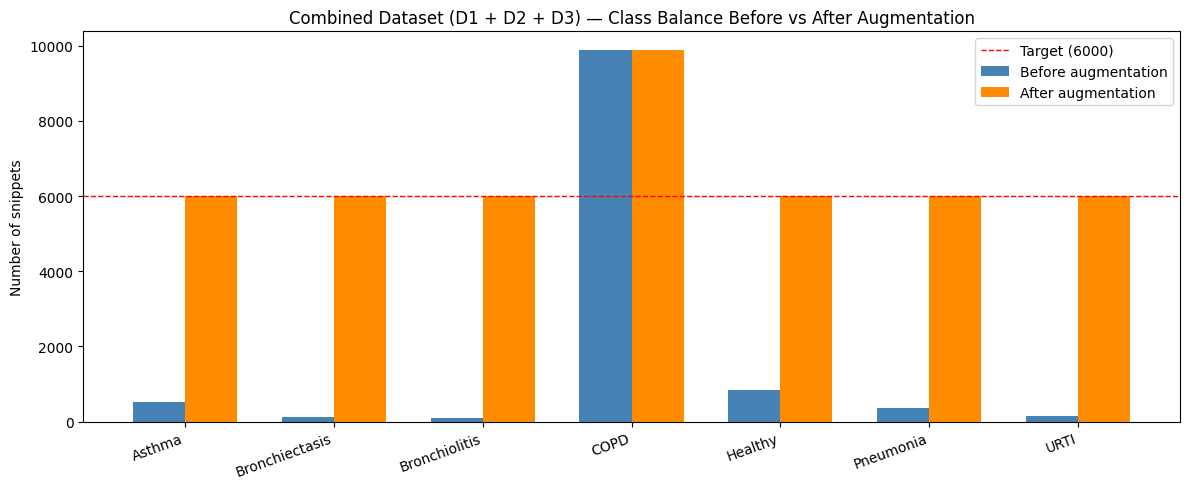

In [ ]:
# ── Cell 16 : Class distribution plot — before vs after augmentation ──────────
before_counts = [(y_combined_lbl == i).sum() for i in range(len(COMBINED_CLASSES))]
after_counts  = [(y_aug == i).sum()          for i in range(len(COMBINED_CLASSES))]

x = np.arange(len(COMBINED_CLASSES))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, before_counts, w, label='Before augmentation', color='steelblue')
ax.bar(x + w/2, after_counts,  w, label='After augmentation',  color='darkorange')
ax.axhline(TARGET_PER_CLASS, color='red', linestyle='--', linewidth=1, label=f'Target ({TARGET_PER_CLASS})')
ax.set_xticks(x)
ax.set_xticklabels(COMBINED_CLASSES, rotation=20, ha='right')
ax.set_ylabel('Number of snippets')
ax.set_title('Combined Dataset (D1 + D2 + D3) — Class Balance Before vs After Augmentation')
ax.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR_COMBINED}/class_balance.png', dpi=150)
plt.show()

---
## Part G — RDLINet 5-Fold Training & Testing on Combined Dataset


Input shape   : (64, 38, 3)
Classes (7)  : ['Asthma', 'Bronchiectasis', 'Bronchiolitis', 'COPD', 'Healthy', 'Pneumonia', 'URTI']
Total samples : 45888

  FOLD 1 / 5  [D1_D2_D3_Combined]
Epoch 1/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 58s 87ms/step - accuracy: 0.6865 - loss: 0.7970 - val_accuracy: 0.3893 - val_loss: 2.6573 - learning_rate: 0.0080
Epoch 2/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8421 - loss: 0.4042 - val_accuracy: 0.2769 - val_loss: 10.6458 - learning_rate: 0.0080
Epoch 3/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8792 - loss: 0.3066 - val_accuracy: 0.6708 - val_loss: 1.4923 - learning_rate: 0.0080
Epoch 4/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9007 - loss: 0.2510 - val_accuracy: 0.5538 - val_loss: 2.5176 - learning_rate: 0.0080
Epoch 5/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9145 - loss: 0.2160 - val_accuracy: 0.5236 - val_loss: 4.3184 - learning_rate: 0.0080
Epoch 6/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 4

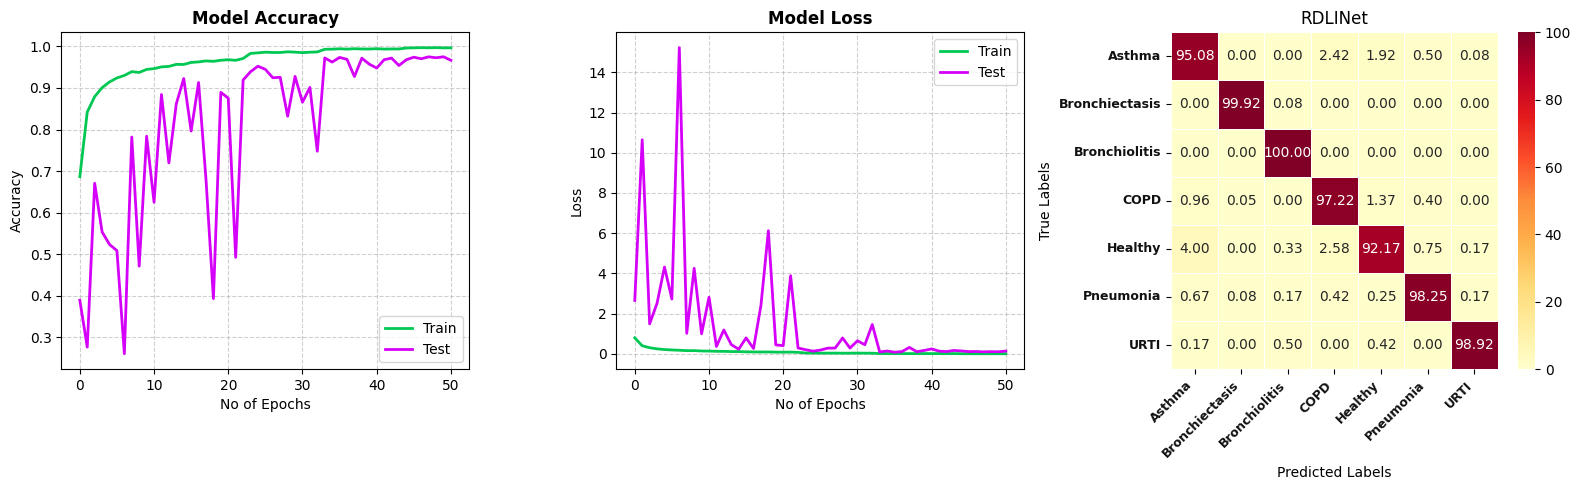

Fold 1 weights saved.

  FOLD 2 / 5  [D1_D2_D3_Combined]
Epoch 1/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 36s 58ms/step - accuracy: 0.6901 - loss: 0.7927 - val_accuracy: 0.3000 - val_loss: 2.9840 - learning_rate: 0.0080
Epoch 2/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8426 - loss: 0.4054 - val_accuracy: 0.6834 - val_loss: 1.3398 - learning_rate: 0.0080
Epoch 3/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8822 - loss: 0.3004 - val_accuracy: 0.4449 - val_loss: 4.1044 - learning_rate: 0.0080
Epoch 4/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9002 - loss: 0.2542 - val_accuracy: 0.6409 - val_loss: 1.7094 - learning_rate: 0.0080
Epoch 5/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9144 - loss: 0.2207 - val_accuracy: 0.5996 - val_loss: 1.7135 - learning_rate: 0.0080
Epoch 6/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9229 - loss: 0.1967 - val_accuracy: 0.7474 - val_loss: 1.0858 - learning_rate: 0.0080
Epoch 7/300
287/28

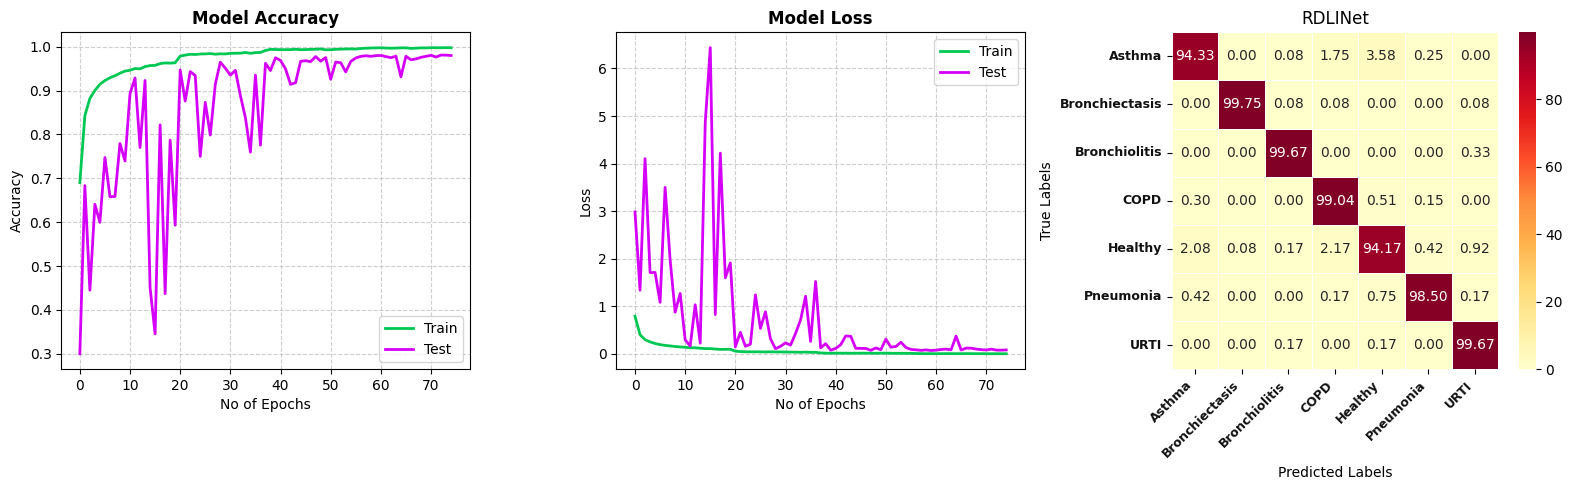

Fold 2 weights saved.

  FOLD 3 / 5  [D1_D2_D3_Combined]
Epoch 1/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 35s 54ms/step - accuracy: 0.6978 - loss: 0.7730 - val_accuracy: 0.4623 - val_loss: 1.7725 - learning_rate: 0.0080
Epoch 2/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8442 - loss: 0.3963 - val_accuracy: 0.3523 - val_loss: 4.7684 - learning_rate: 0.0080
Epoch 3/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8800 - loss: 0.3044 - val_accuracy: 0.2406 - val_loss: 16.0033 - learning_rate: 0.0080
Epoch 4/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9006 - loss: 0.2517 - val_accuracy: 0.4627 - val_loss: 4.0995 - learning_rate: 0.0080
Epoch 5/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9122 - loss: 0.2215 - val_accuracy: 0.3867 - val_loss: 4.3749 - learning_rate: 0.0080
Epoch 6/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9202 - loss: 0.2024 - val_accuracy: 0.7390 - val_loss: 0.9603 - learning_rate: 0.0080
Epoch 7/300
287/2

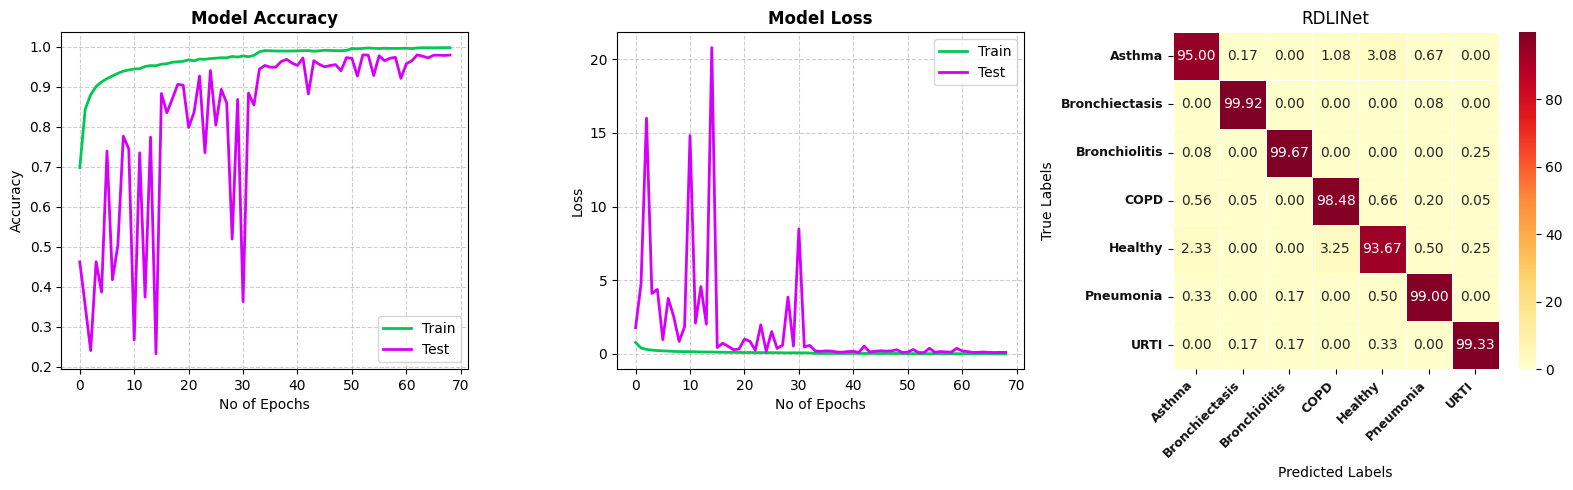

Fold 3 weights saved.

  FOLD 4 / 5  [D1_D2_D3_Combined]
Epoch 1/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - accuracy: 0.6885 - loss: 0.8036 - val_accuracy: 0.5153 - val_loss: 1.7369 - learning_rate: 0.0080
Epoch 2/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8415 - loss: 0.4097 - val_accuracy: 0.7619 - val_loss: 0.7487 - learning_rate: 0.0080
Epoch 3/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8822 - loss: 0.2980 - val_accuracy: 0.5893 - val_loss: 1.7254 - learning_rate: 0.0080
Epoch 4/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9002 - loss: 0.2527 - val_accuracy: 0.6317 - val_loss: 1.6296 - learning_rate: 0.0080
Epoch 5/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9110 - loss: 0.2225 - val_accuracy: 0.8228 - val_loss: 0.6826 - learning_rate: 0.0080
Epoch 6/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9219 - loss: 0.1967 - val_accuracy: 0.6746 - val_loss: 1.3337 - learning_rate: 0.0080
Epoch 7/300
287/28

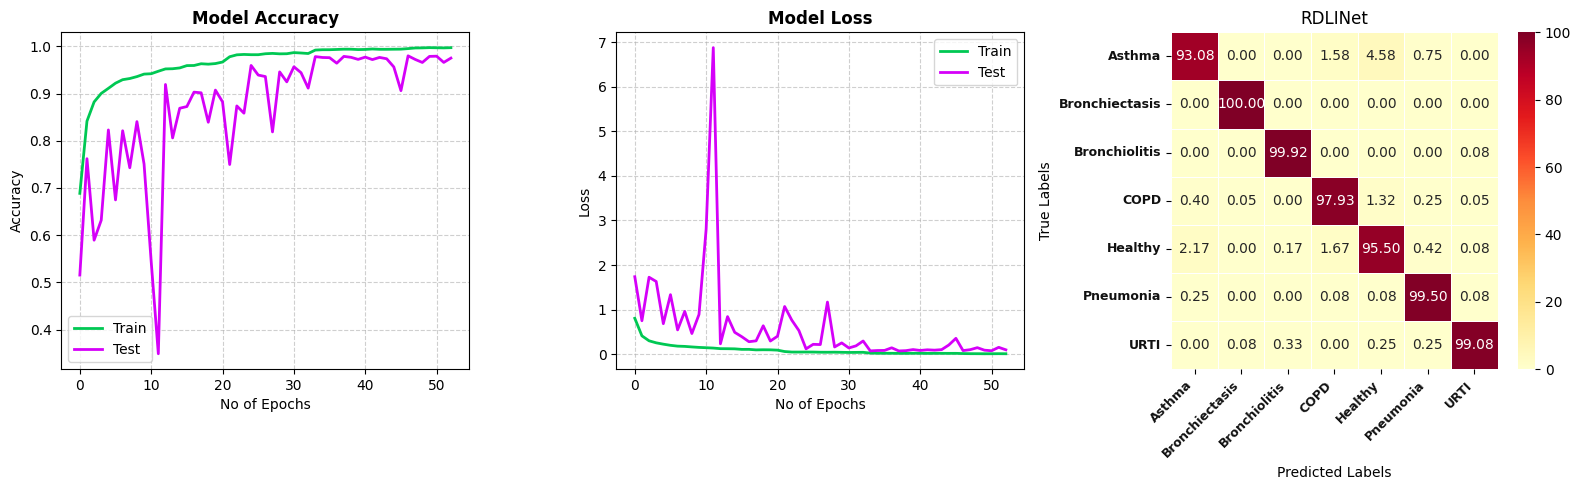

Fold 4 weights saved.

  FOLD 5 / 5  [D1_D2_D3_Combined]
Epoch 1/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 36s 58ms/step - accuracy: 0.6962 - loss: 0.7812 - val_accuracy: 0.4024 - val_loss: 2.9534 - learning_rate: 0.0080
Epoch 2/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8467 - loss: 0.3873 - val_accuracy: 0.6630 - val_loss: 1.2214 - learning_rate: 0.0080
Epoch 3/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8844 - loss: 0.2907 - val_accuracy: 0.8544 - val_loss: 0.4359 - learning_rate: 0.0080
Epoch 4/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9039 - loss: 0.2469 - val_accuracy: 0.6113 - val_loss: 1.7731 - learning_rate: 0.0080
Epoch 5/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9162 - loss: 0.2145 - val_accuracy: 0.2464 - val_loss: 11.5440 - learning_rate: 0.0080
Epoch 6/300
287/287 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9242 - loss: 0.1925 - val_accuracy: 0.7275 - val_loss: 0.9097 - learning_rate: 0.0080
Epoch 7/300
287/2

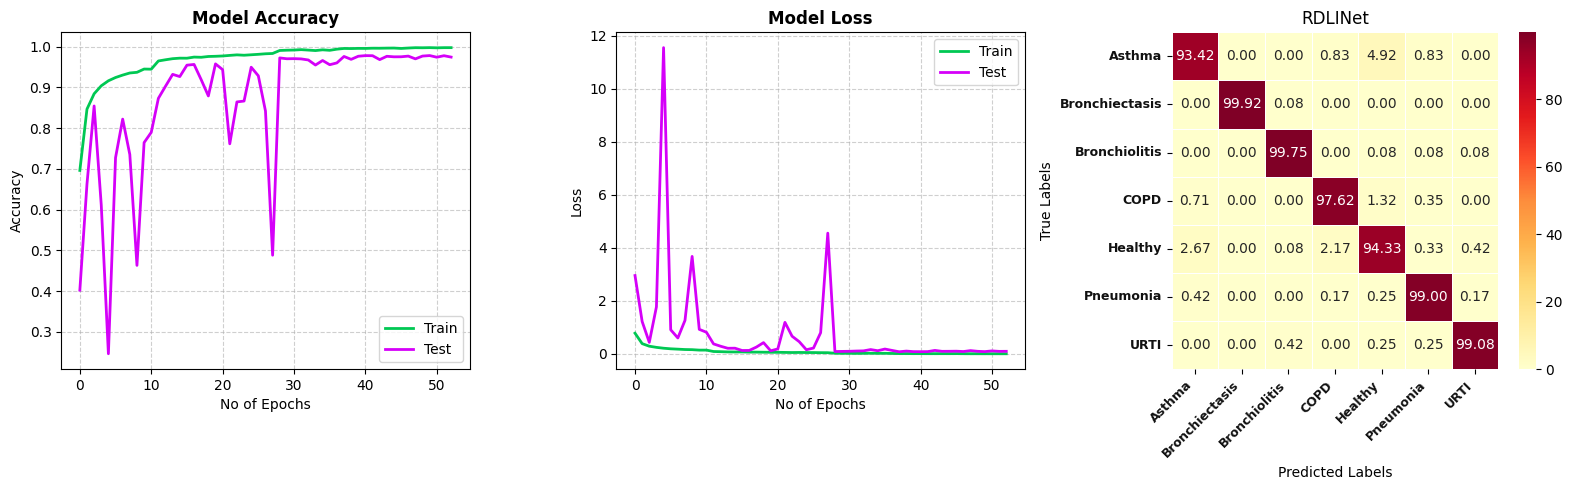

Fold 5 weights saved.

FINAL RESULTS — D1_D2_D3_Combined
  Fold 1 : 97.3524%
  Fold 2 : 97.9734%
  Fold 3 : 97.9189%
  Fold 4 : 97.8642%
  Fold 5 : 97.5918%
  Mean  : 97.7401%
  Std   : 0.2342%


In [ ]:
# ── Cell 20 : Train RDLINet on D1 + D2 + D3 combined ────────────────────────
combined_scores = run_kfold_training(
    X_aug, Y_aug, y_aug,
    class_list  = COMBINED_CLASSES,
    results_dir = RESULTS_DIR_COMBINED,
    tag         = 'D1_D2_D3_Combined',
    n_splits    = 5,
    epochs      = 300,
    batch_size  = 128,
    lr          = 0.008
)
